In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from utils.dataset.clickstream_generator import generate_clickstream

[INFO] Font applied: NanumGothic


# Dataset Path

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

# Clickstream Dataset
- 가상의 클릭 스트림 데이터 생성

In [3]:
generate_clickstream(
    user_metadata_path=paths.user_metadata_path,  # 유저 메타데이터 parquet 파일
    item_metadata_path=paths.item_metadata_path,  # 아이템 메타데이터 parquet 파일
    save_path=paths.user_logs_path,  # 생성된 클릭스트림 parquet 파일 저장 경로
    users_per_chunk=1000,  # 유저별 로그를 나누어 저장할 단위 (1000명씩 저장)
    n_sessions_per_user=5,  # 각 유저가 가질 세션 개수
    actions=["click", "wishlist", "cart", "purchase"],  # 행동 유형
    action_weights=[0.8, 0.1, 0.05, 0.05],  # 행동별 확률
    similarity_keys=[
        "gender",
        "age_group",
        "season",
        "master_category",
        "sub_category",
        "article_type",
        "usage",
    ],  # 유사 아이템을 묶을 기준
    start_date=datetime(2025, 9, 1),  # 클릭 로그 시작 시점
    seed=42,  # 랜덤 시드 (재현성)
)

# Load Dataset

In [4]:
df = pd.read_parquet(paths.user_logs_path)

In [5]:
df.shape

(218233, 21)

In [6]:
df.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,3548,2025-09-21 03:01:00,click,46,Women,Colorbar Velvet Matte Iced Tea Lipstick 19 BR,Colorbar,325.0,325.0,...,Brown,Spring,2017,Casual,Personal Care,Lips,Lipstick,<UNK>,<UNK>,"Nourished with Vitamin E, its unique 2-in-1 fo..."
1,1,3383,2025-09-21 03:02:00,click,46,Women,Lakme Absolute Matte Classic Rose Lipstick 47,Lakme,525.0,472.0,...,Red,Spring,2017,Casual,Personal Care,Lips,Lipstick,<UNK>,<UNK>,"Lakme Absolute Matte lipstick, luxurious rich ..."
2,1,1937,2025-09-21 03:05:00,click,46,Women,Colorbar Take Me As I Am Mischievous Wine Lips...,Colorbar,900.0,720.0,...,Red,Spring,2017,Casual,Personal Care,Lips,Lipstick,<UNK>,<UNK>,<span>Multifunctional lip colour styled like a...
3,1,9109,2025-09-21 03:04:00,click,46,Women,Lakme Absolute Matte Pink Romance Lipstick 206,Lakme,500.0,450.0,...,Pink,Spring,2017,Casual,Personal Care,Lips,Lipstick,<UNK>,<UNK>,"Lakme Absolute Matte lipstick, luxurious rich ..."
4,1,1626,2025-09-21 03:17:00,click,46,Women,Lakme Absolute Matte Merlot Lipstick 45,Lakme,525.0,472.0,...,Brown,Spring,2017,Casual,Personal Care,Lips,Lipstick,<UNK>,<UNK>,"Lakme Absolute Matte lipstick, luxurious lip c..."


# EDA

## Item Frequency

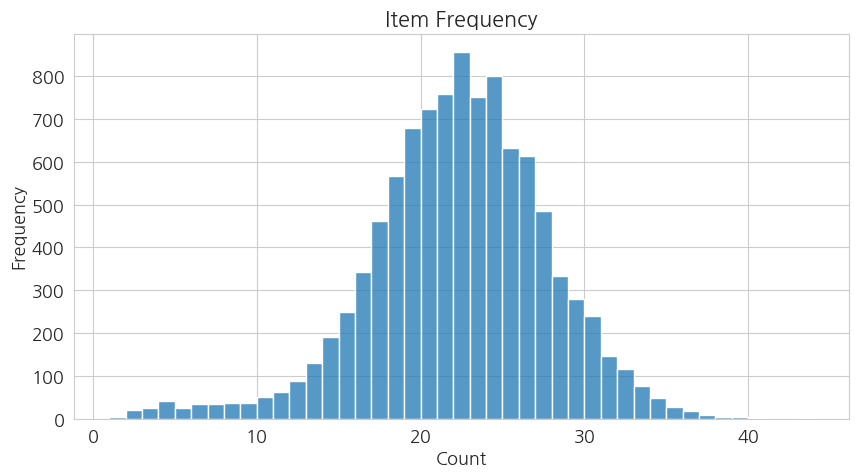

In [7]:
# - `item_id`별 등장 횟수를 세어 분포 확인
# - 인기 아이템과 Long-tail 아이템을 직관적으로 볼 수 있음
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(x=df["item_id"].value_counts(), binwidth=1)
plt.title("Item Frequency")
plt.xlabel("Count")  # 특정 아이템이 등장한 횟수
plt.ylabel("Frequency")  # 등장 횟수별 아이템의 개수
plt.show()